<a href="https://colab.research.google.com/github/dmitrii-krasnikov/anytask_AESC/blob/main/task_numpy_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ДЗ №1 СУНЦ МГУ - Numpy practice

In [ ]:
%%writefile functions.py
import math

def prod_non_zero_diag(x):
    prod = 1
    has_nonzero = False

    lim = min(len(x), len(x[0]))
    for i in range(lim):
        elem = x[i][i]
        if elem != 0:
            prod = prod * elem
            has_nonzero = True

    if has_nonzero:
        return prod
    else:
        return 0

def are_multisets_equal(x, y):
    list_x = list(x)
    list_y = list(y)

    list_x.sort()
    list_y.sort()

    return list_x == list_y

def max_after_zero(x):
    max_val = None

    for i in range(len(x) - 1):
        if x[i] == 0:
            next_element = x[i + 1]
            if max_val is None or next_element > max_val:
                max_val = next_element

    return max_val

def convert_image(img, coefs):
    h = len(img)
    w = len(img[0])
    c = len(img[0][0])

    res = []
    for i in range(h):
        row = []
        for j in range(w):
            row.append(0.0)
        res.append(row)

    for i in range(h):
        for j in range(w):
            pixel_sum = 0.0
            for k in range(c):
                pixel_sum = pixel_sum + (img[i][j][k] * coefs[k])
            res[i][j] = pixel_sum

    return res

def run_length_encoding(x):
    if len(x) == 0:
        return [], []

    elements = []
    counters = []

    curr_element = x[0]
    count = 1

    for i in range(1, len(x)):
        if x[i] == curr_element:
            count = count + 1
        else:
            elements.append(curr_element)
            counters.append(count)
            curr_element = x[i]
            count = 1

    elements.append(curr_element)
    counters.append(count)

    return elements, counters

def pairwise_distance(x, y):
    res = []
    for i in range(len(x)):
        row = []
        for j in range(len(y)):
            row.append(0.0)
        res.append(row)
    for i in range(len(x)):
        for j in range(len(y)):
            dist_squared = 0.0
            for k in range(len(x[i])):
                diff = x[i][k] - y[j][k]
                dist_squared = dist_squared + (diff * diff)
            res[i][j] = math.sqrt(dist_squared)

    return res

Overwriting functions.py


In [ ]:
%%writefile functions_vectorized.py
import numpy as np

import numpy as np

def prod_non_zero_diag(x):
    diag = np.diagonal(x)
    mask = (diag != 0)
    nonzero_diag = diag[mask]
    if len(nonzero_diag) > 0:
        return np.prod(nonzero_diag)
    else:
        return 0

def are_multisets_equal(x, y):
    sorted_x = np.sort(x)
    sorted_y = np.sort(y)
    return np.array_equal(sorted_x, sorted_y)

def max_after_zero(x):
    shifted_x = np.roll(x, 1)
    mask = (shifted_x == 0)
    mask[0] = False

    valid_elements = x[mask]

    if len(valid_elements) == 0:
        return None
    return np.max(valid_elements)

def convert_image(img, coefs):
    return np.dot(img, coefs)

def run_length_encoding(x):
    if len(x) == 0:
        return np.array([]), np.array([])

    shifted_x = np.roll(x, 1)
    is_new_run = (x != shifted_x)
    is_new_run[0] = True

    run_starts = np.where(is_new_run)[0]
    elements = x[run_starts]

    run_starts_with_end = np.append(run_starts, len(x))
    counters = np.diff(run_starts_with_end)

    return elements, counters

def pairwise_distance(x, y):
    x_squared = np.sum(x ** 2, axis=1, keepdims=True)
    y_squared = np.sum(y ** 2, axis=1)
    xy = np.dot(x, y.T)
    dist_squared = x_squared - (2 * xy) + y_squared
    dist_squared = np.maximum(dist_squared, 0)
    return np.sqrt(dist_squared)

Writing functions_vectorized.py


In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np
import scipy.spatial

import functions
import functions_vectorized

def plot_benchmark(func_non_vec, func_vec, data_gen, sizes, title, add_scipy=None):
    times_non_vec = []
    times_vec = []
    times_scipy = []

    for size in sizes:

        list_data, np_data = data_gen(size)

        start = time.perf_counter()
        func_non_vec(*list_data)
        times_non_vec.append(time.perf_counter() - start)

        start = time.perf_counter()
        func_vec(*np_data)
        times_vec.append(time.perf_counter() - start)

        if add_scipy:
            start = time.perf_counter()
            add_scipy(*np_data)
            times_scipy.append(time.perf_counter() - start)

    plt.figure(figsize=(8, 5))
    plt.plot(sizes, times_non_vec, label="Невекторизованная", marker='o')
    plt.plot(sizes, times_vec, label="Векторизованная", marker='s')
    if add_scipy:
        plt.plot(sizes, times_scipy, label="Scipy (cdist)", marker='^', linestyle='--')

    plt.title(title)
    plt.xlabel("Размер данных")
    plt.ylabel("Время работы (с)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

**Среда:** Python 3.14.7. Локальные модули `functions.py` и `functions_vectorized.py` повторно импортируются при каждом запуске ячейки с решением.


### Туториальные задачи
__(9 баллов)__

Ниже приведены задачи на работу с numpy-массивами. Для каждой из задач нужно привести 2 реализации: одна без использования numpy (cчитайте, что там, где на входе или выходе должны быть numpy array, будут просто списки), а вторая полностью векторизованная (без использования питоновских циклов/map/list comprehension). Невекторизованная реализация каждой из задач оценивается в __0.5 балла__, векторизованная – в __1 балл__.

Реализации без использования векторизации нужно записать в файл functions.py, а векторизованные &mdash; в файл functions_vectorized.py

Для каждой задачи, приведённой ниже сравните скорость работы невекторизованной и векторизованной реализации. С помощью пакета matplotlib постройте графики времени работы в зависимости от размера данных. __Графики должны выглядеть опрятно!__ То есть должны быть подписаны оси, названия графиков, и т.д. Например, ниже представлены хороший и плохой графики:

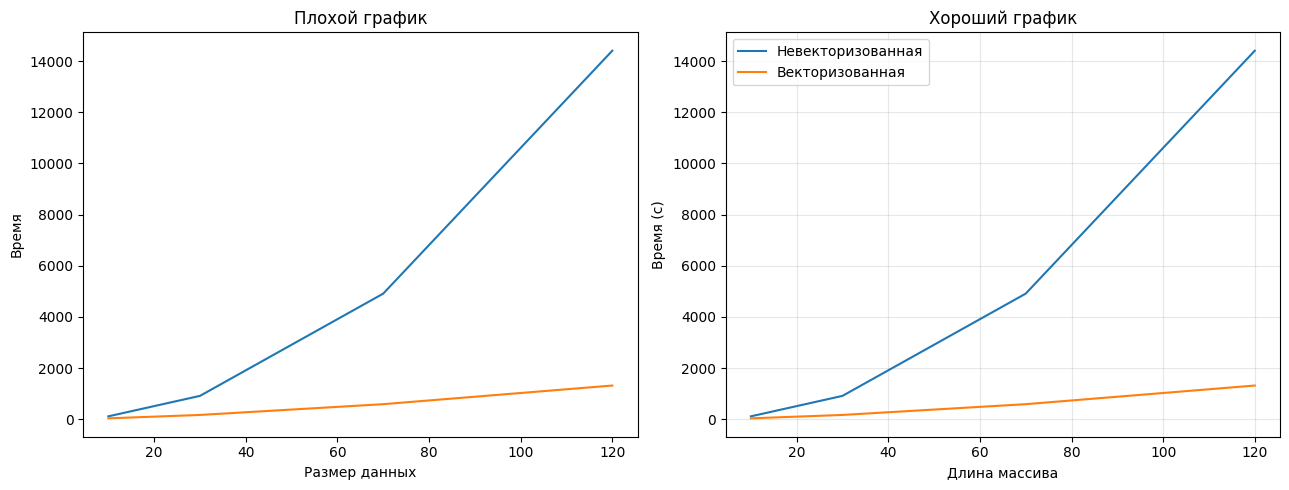

In [ ]:
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np

import functions
import functions_vectorized

%matplotlib inline


def reload_solution_modules():
    """Reload the two local solution modules after their files change."""
    reload(functions)
    reload(functions_vectorized)


data_size = np.array([10, 30, 70, 120])
time_non_vectorized = data_size**2 + 10
time_vectorized = data_size**1.5

figure, (axis_bad, axis_good) = plt.subplots(1, 2, figsize=(13, 5))

axis_bad.plot(data_size, time_non_vectorized)
axis_bad.plot(data_size, time_vectorized)
axis_bad.set_title("Плохой график")
axis_bad.set_xlabel("Размер данных")
axis_bad.set_ylabel("Время")

axis_good.plot(data_size, time_non_vectorized, label="Невекторизованная")
axis_good.plot(data_size, time_vectorized, label="Векторизованная")
axis_good.set_title("Хороший график")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
plt.show()


* __Задача 1__: Подсчитать произведение ненулевых элементов на диагонали прямоугольной матрицы.  
 Например, для X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]) ответ – 3.

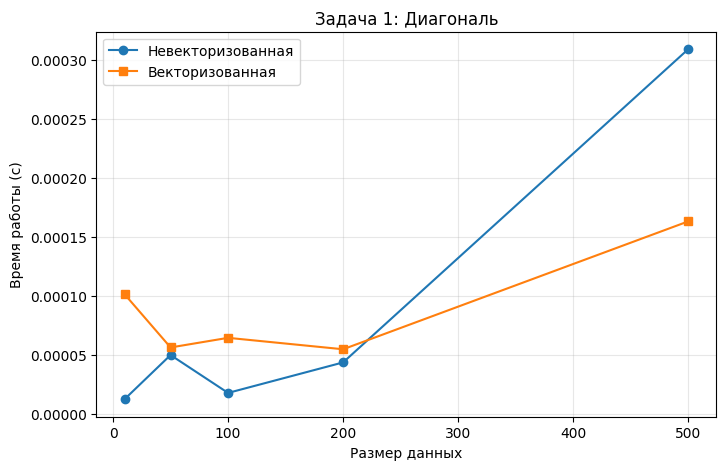

In [ ]:
reload_solution_modules()

def data_gen_1(size):
    arr = np.random.randint(0, 10, size=(size, size))
    return (arr.tolist(),), (arr,)

sizes = [10, 50, 100, 200, 500]
plot_benchmark(functions.prod_non_zero_diag, functions_vectorized.prod_non_zero_diag, data_gen_1, sizes, "Задача 1: Диагональ")



* __Задача 2__: Даны два вектора x и y. Проверить, задают ли они одно и то же мультимножество.  
  Например, для x = np.array([1, 2, 2, 4]), y = np.array([4, 2, 1, 2]) ответ – True.
  
  


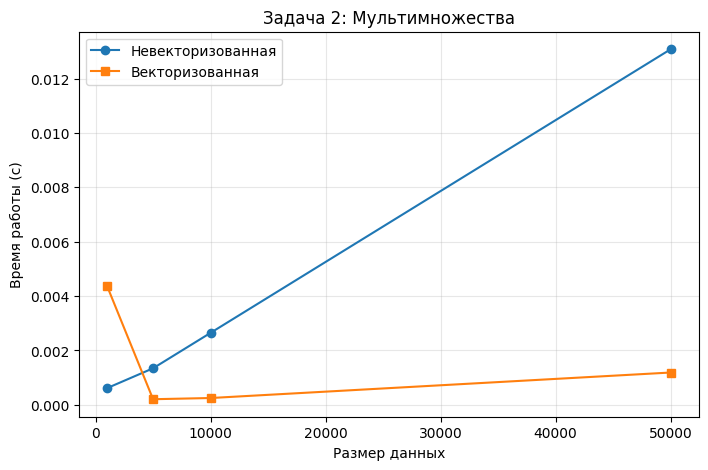

In [ ]:
reload_solution_modules()

def data_gen_2(size):
    arr1 = np.random.randint(0, 100, size=size)
    arr2 = np.random.permutation(arr1) # Одинаковые элементы
    return (arr1.tolist(), arr2.tolist()), (arr1, arr2)

sizes = [1000, 5000, 10000, 50000]
plot_benchmark(functions.are_multisets_equal, functions_vectorized.are_multisets_equal, data_gen_2, sizes, "Задача 2: Мультимножества")

* __Задача 3__: Найти максимальный элемент в векторе x среди элементов, перед которыми стоит нулевой.  
 Например, для x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0]) ответ – 5.

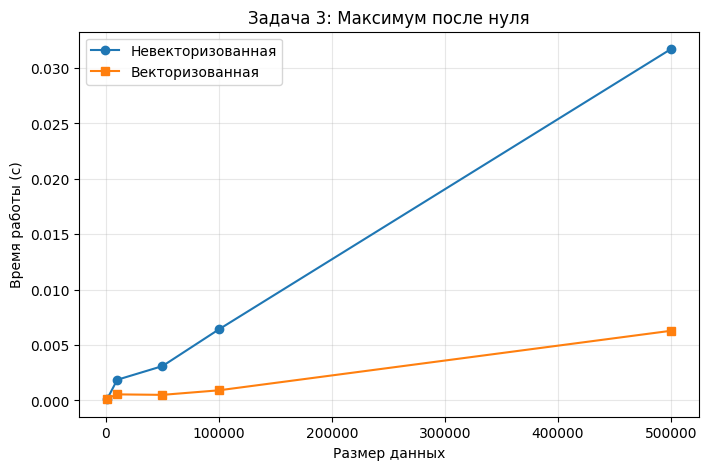

In [ ]:
reload_solution_modules()

def data_gen_3(size):
    arr = np.random.randint(0, 5, size=size) # Много нулей
    return (arr.tolist(),), (arr,)

sizes = [1000, 10000, 50000, 100000, 500000]
plot_benchmark(functions.max_after_zero, functions_vectorized.max_after_zero, data_gen_3, sizes, "Задача 3: Максимум после нуля")




* __Задача 4__: Дан трёхмерный массив, содержащий изображение, размера (height, width, numChannels), а также вектор длины numChannels. Сложить каналы изображения с указанными весами, и вернуть результат в виде матрицы размера (height, width). В ноутбуке приведите пример работы функции – преобразуйте цветное изображение в оттенки серого, использовав коэффициенты np.array([0.299, 0.587, 0.114]). Считать реальное изображение можно с помощью `PIL.Image.open` из пакета Pillow: `img = np.asarray(Image.open(path).convert("RGB"))`. Устаревшая функция `scipy.misc.imread` удалена из современных версий SciPy.


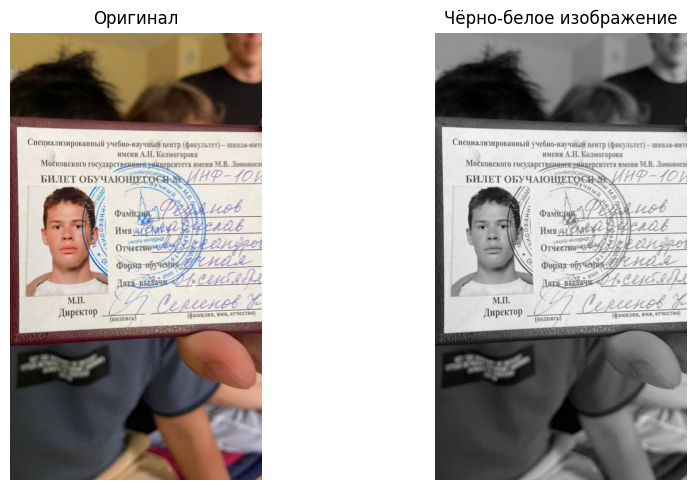

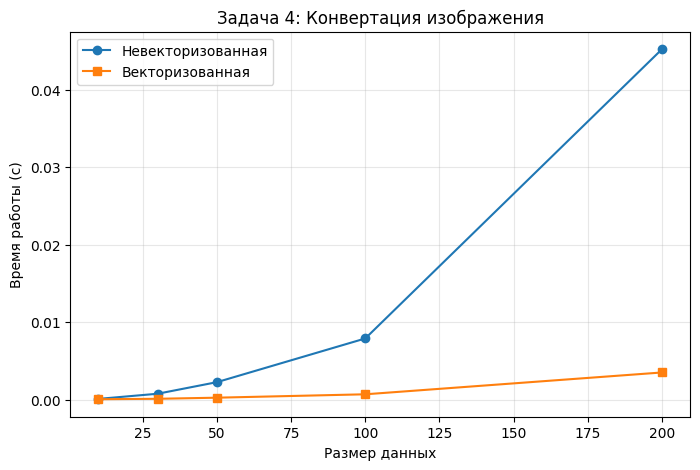

In [ ]:
reload_solution_modules()

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

import functions_vectorized


image_path = "/photo_2026-08-31_23-17-36.jpg"
img = np.asarray(Image.open(image_path).convert("RGB"))
coefs = np.array([0.299, 0.587, 0.114])
res_img = functions_vectorized.convert_image(img, coefs)
figure, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(img)
ax1.set_title("Оригинал")
ax1.axis('off')

ax2.imshow(res_img, cmap='gray')
ax2.set_title("Чёрно-белое изображение")
ax2.axis('off')

plt.tight_layout()
plt.show()


def data_gen_4(size):
    arr = np.random.randint(0, 255, size=(size, size, 3))
    w = np.array([0.299, 0.587, 0.114])
    return (arr.tolist(), w.tolist()), (arr, w)

sizes = [10, 30, 50, 100, 200]
plot_benchmark(functions.convert_image, functions_vectorized.convert_image, data_gen_4, sizes, "Задача 4: Конвертация изображения")


* __Задача 5__: Реализовать кодирование длин серий (Run-length encoding). Для некоторого вектора x необходимо вернуть кортеж из двух векторов одинаковой длины. Первый содержит числа, а второй - сколько раз их нужно повторить.  
 Например, для x = np.array([2, 2, 2, 3, 3, 3, 5]) ответ – (np.array([2, 3, 5]), np.array([3, 3, 1])).

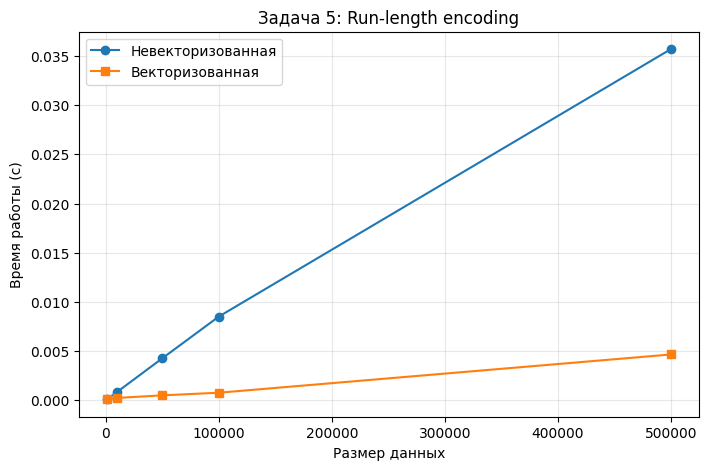

In [ ]:
reload_solution_modules()

def data_gen_5(size):
    arr = np.repeat(np.random.randint(0, 10, size=size//5 + 1), 5)[:size]
    return (arr.tolist(),), (arr,)

sizes = [1000, 10000, 50000, 100000, 500000]
plot_benchmark(functions.run_length_encoding, functions_vectorized.run_length_encoding, data_gen_5, sizes, "Задача 5: Run-length encoding")




* __Задача 6__: Даны две выборки объектов - X и Y. Вычислить матрицу евклидовых расстояний между объектами. Дополнительно сравните с функцией scipy.spatial.distance.cdist по скорости работы (сравнения приведите ниже в ноутбуке).

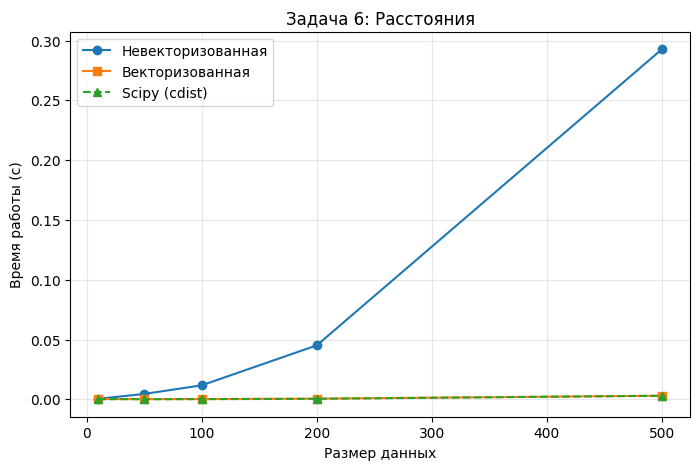

In [ ]:
reload_solution_modules()

def data_gen_6(size):
    arr1 = np.random.rand(size, 10) # 10 признаков
    arr2 = np.random.rand(size, 10)
    return (arr1.tolist(), arr2.tolist()), (arr1, arr2)

sizes = [10, 50, 100, 200, 500]
plot_benchmark(functions.pairwise_distance, functions_vectorized.pairwise_distance, data_gen_6, sizes, "Задача 6: Расстояния", add_scipy=scipy.spatial.distance.cdist)


### Туториал по Markdown

__(1 балл)__

Напишите краткий (а в данной домашке ещё и почти бесмысленный) отчёт с использованием 4-5 различных вариантов разметки/выделения текста.

In [ ]:
# Краткий отчет по работе

В ходе выполнения данного домашнего задания мы сравнили производительность векторизованных алгоритмов и невекторизованных аналогов на языке Python.

## Основные выводы
1. Использование библиотеки numpy позволяет сильно ускорить выполнение вычислений.
2. Векторизация кода убирает необходимость использовать медленные вложенные циклы for.

Эффективность векторизации возрастает нелинейно при увеличении объемов обрабатываемых массивов данных.
